# BTC Trend Following Single Asset

In [1]:
from datetime import UTC, datetime

import data
import research

In [2]:
research.set_seed(123)

sym = "BTCUSDT"
interval = "1h"
forecast_horizon = 1
annualized_rate = research.sharpe_to_annualized_rate(interval, 365, 24)
start_date = datetime(2025, 1, 1, 0, 0, tzinfo=UTC)
end_date = datetime(2026, 1, 1, 0, 0, tzinfo=UTC)

data.download_date_range(sym, start_date, end_date)

In [3]:
ts = research.load_ohlc_timeseries_range(sym, interval, start_date, end_date)
ts

datetime,open,high,low,close,volume
datetime[μs],f64,f64,f64,f64,f64
2025-01-01 00:00:00,93548.8,94449.2,93460.2,94363.6,5744.609
2025-01-01 01:00:00,94363.6,94363.7,93545.0,93588.0,3991.464
2025-01-01 02:00:00,93587.9,94082.4,93561.8,94064.4,2297.236
2025-01-01 03:00:00,94064.4,94070.2,93692.6,93810.0,1928.71
2025-01-01 04:00:00,93810.0,93810.1,93502.0,93545.0,2241.616
…,…,…,…,…,…
2026-01-01 19:00:00,88165.2,88403.8,88034.7,88354.8,1711.864
2026-01-01 20:00:00,88354.8,88354.8,88193.2,88220.4,1285.863
2026-01-01 21:00:00,88220.5,88400.0,88211.8,88346.9,932.263


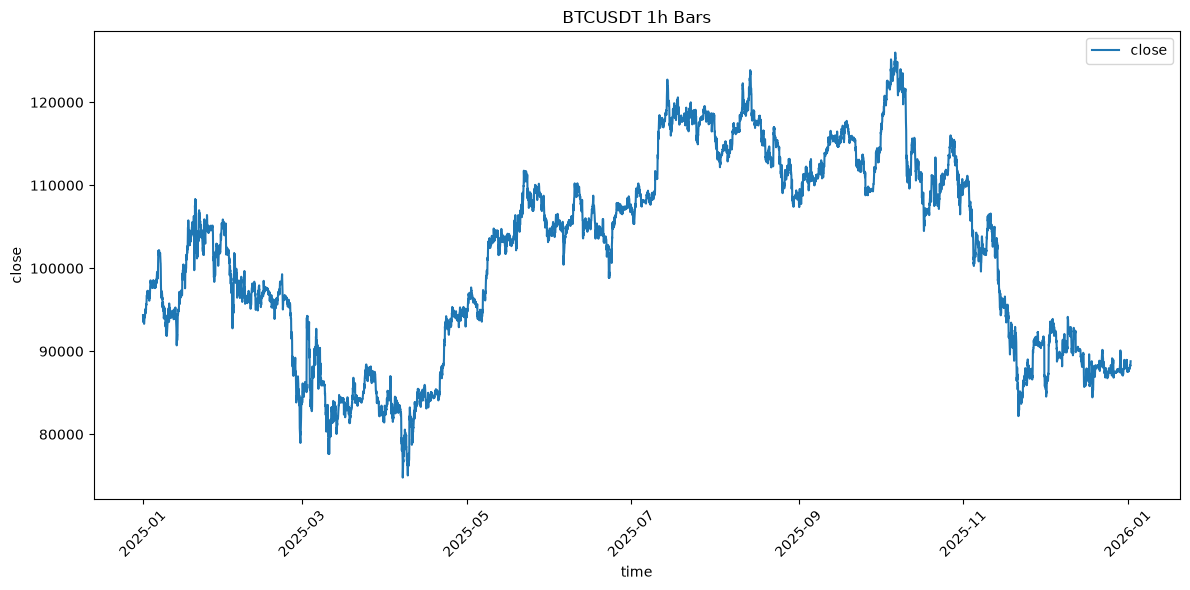

In [4]:
research.plot_timeseries(ts, sym, "close", interval)

In [5]:
# Momentum features: rolling sum of past N log returns (opposite of mean reversion's single lag)

import polars as pl

target = "close_log_return"
ts = ts.with_columns((pl.col("close") / pl.col("close").shift(1)).log().alias(target))
ts

datetime,open,high,low,close,volume,close_log_return
datetime[μs],f64,f64,f64,f64,f64,f64
2025-01-01 00:00:00,93548.8,94449.2,93460.2,94363.6,5744.609,null
2025-01-01 01:00:00,94363.6,94363.7,93545.0,93588.0,3991.464,-0.008253
2025-01-01 02:00:00,93587.9,94082.4,93561.8,94064.4,2297.236,0.005077
2025-01-01 03:00:00,94064.4,94070.2,93692.6,93810.0,1928.71,-0.002708
2025-01-01 04:00:00,93810.0,93810.1,93502.0,93545.0,2241.616,-0.002829
…,…,…,…,…,…,…
2026-01-01 19:00:00,88165.2,88403.8,88034.7,88354.8,1711.864,0.002147
2026-01-01 20:00:00,88354.8,88354.8,88193.2,88220.4,1285.863,-0.001522
2026-01-01 21:00:00,88220.5,88400.0,88211.8,88346.9,932.263,0.001433


In [6]:
momentum_windows = [2, 3, 5, 8, 13, 21, 34]

momentum_cols = []
for w in momentum_windows:
    col_name = f"momentum_{w}"
    ts = ts.with_columns(
        pl.col(target)
        .rolling_sum(window_size=w)
        .shift(forecast_horizon)
        .alias(col_name)
    )
    momentum_cols.append(col_name)

ts = ts.drop_nulls()
ts

datetime,open,high,low,close,volume,close_log_return,momentum_2,momentum_3,momentum_5,momentum_8,momentum_13,momentum_21,momentum_34
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2025-01-02 11:00:00,96693.9,96870.9,96438.4,96715.4,4864.523,0.000222,0.005898,0.009128,0.011592,0.015332,0.018069,0.028307,0.024395
2025-01-02 12:00:00,96715.4,96888.6,96575.2,96829.9,5272.205,0.001183,-0.000068,0.00612,0.011924,0.017896,0.020313,0.026913,0.03287
2025-01-02 13:00:00,96830.0,96991.8,96403.9,96426.1,6788.169,-0.004179,0.001406,0.001115,0.010533,0.011751,0.0235,0.02531,0.028976
2025-01-02 14:00:00,96426.0,97440.0,95910.8,97216.3,26301.626,0.008161,-0.002996,-0.002773,0.003124,0.008819,0.01372,0.024737,0.027505
2025-01-02 15:00:00,97216.7,97295.2,96112.4,96428.5,14355.632,-0.008137,0.003983,0.005166,0.005098,0.01709,0.024676,0.032329,0.038496
…,…,…,…,…,…,…,…,…,…,…,…,…,…
2026-01-01 19:00:00,88165.2,88403.8,88034.7,88354.8,1711.864,0.002147,0.002388,0.002027,0.003336,0.003766,0.00558,0.004562,-0.002559
2026-01-01 20:00:00,88354.8,88354.8,88193.2,88220.4,1285.863,-0.001522,0.000832,0.004535,0.004961,0.00425,0.008334,0.007488,-0.002991
2026-01-01 21:00:00,88220.5,88400.0,88211.8,88346.9,932.263,0.001433,0.000625,-0.00069,0.002651,0.003653,0.007015,0.006964,-0.0066


In [7]:
ts.select([target] + momentum_cols).corr()

close_log_return,momentum_2,momentum_3,momentum_5,momentum_8,momentum_13,momentum_21,momentum_34
f64,f64,f64,f64,f64,f64,f64,f64
1.0,-0.001241,-0.010006,0.006946,-0.003929,-0.008864,-0.021598,-0.029456
-0.001241,1.0,0.814593,0.633659,0.494984,0.385895,0.294239,0.220924
-0.010006,0.814593,1.0,0.776002,0.612205,0.472454,0.363635,0.270035
0.006946,0.633659,0.776002,1.0,0.791141,0.611791,0.472521,0.3496
-0.003929,0.494984,0.612205,0.791141,1.0,0.780315,0.600755,0.444663
-0.008864,0.385895,0.472454,0.611791,0.780315,1.0,0.774672,0.566581
-0.021598,0.294239,0.363635,0.472521,0.600755,0.774672,1.0,0.752084
-0.029456,0.220924,0.270035,0.3496,0.444663,0.566581,0.752084,1.0


In [8]:
# look for the best momentum from the above

from torch import nn


class LinearModel(nn.Module):
    def __init__(self, input_features):
        super().__init__()
        self.linear = nn.Linear(input_features, 1)

    def forward(self, x):
        return self.linear(x)

In [9]:
intervals = ["1h", "6h", "12h"]
loss_fns = {
    "mse": nn.MSELoss(),
    "l1": nn.L1Loss(),
    "huber": nn.HuberLoss(),
}
test_sizes = [0.2, 0.25, 0.3]

all_benchmarks = []

for iv in intervals:
    iv_rate = research.sharpe_to_annualized_rate(iv, 365, 24)
    iv_ts = research.load_ohlc_timeseries_range(sym, iv, start_date, end_date)
    iv_ts = iv_ts.with_columns(
        (pl.col("close") / pl.col("close").shift(1)).log().alias(target)
    )
    iv_cols = []
    for w in momentum_windows:
        col_name = f"momentum_{w}"
        iv_ts = iv_ts.with_columns(
            pl.col(target)
            .rolling_sum(window_size=w)
            .shift(forecast_horizon)
            .alias(col_name)
        )
        iv_cols.append(col_name)
    iv_ts = iv_ts.drop_nulls()

    for loss_name, loss in loss_fns.items():
        for test_size in test_sizes:
            bench = research.benchmark_linear_models(
                iv_ts,
                target,
                iv_cols,
                iv_rate,
                max_no_features=2,
                loss=loss,
                test_size=test_size,
            ).with_columns(
                pl.lit(iv).alias("interval"),
                pl.lit(loss_name).alias("loss"),
                pl.lit(test_size).alias("test_size"),
            )
            all_benchmarks.append(bench)

results = pl.concat(all_benchmarks).sort("sharpe", descending=True)
results.head(15)

features,target,no_bars,no_trades,frac_time_in_market,win_rate,avg_win,avg_loss,best_trade,worst_trade,ev,std,total_log_return,compound_return,max_drawdown,equity_trough,equity_peak,sharpe,interval,loss,test_size
str,str,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str,f64
"""momentum_5,momentum_8""","""close_log_return""",1750,1750,1.0,0.524,0.0036,-0.002968,0.037794,-0.027628,0.000474,0.004988,0.828907,1.290812,-0.088838,0.003146,0.835434,8.888454,"""1h""","""huber""",0.2
"""momentum_5,momentum_8""","""close_log_return""",2188,2188,1.0,0.522852,0.003519,-0.003039,0.037794,-0.027628,0.00039,0.004896,0.852339,1.345125,-0.088838,-0.0301,0.859036,7.447183,"""1h""","""mse""",0.25
"""momentum_5,momentum_13""","""close_log_return""",1750,1750,1.0,0.522286,0.003518,-0.00306,0.037794,-0.027628,0.000376,0.004996,0.65728,0.929538,-0.081593,-0.001013,0.691687,7.036312,"""1h""","""huber""",0.2
"""momentum_5,momentum_13""","""close_log_return""",1750,1750,1.0,0.524571,0.003474,-0.003106,0.037794,-0.027628,0.000346,0.004998,0.60509,0.831417,-0.068557,-0.001013,0.607804,6.474814,"""1h""","""mse""",0.2
"""momentum_5,momentum_8""","""close_log_return""",2188,2188,1.0,0.527879,0.003428,-0.003136,0.037794,-0.033952,0.000329,0.0049,0.719162,1.052713,-0.106662,-0.101855,0.73108,6.277849,"""1h""","""l1""",0.25
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""momentum_2,momentum_8""","""close_log_return""",429,429,1.0,0.505828,0.009043,-0.006537,0.052576,-0.038464,0.001344,0.011705,0.576389,0.7796,-0.145456,-0.077751,0.614613,4.385863,"""6h""","""mse""",0.3
"""momentum_3,momentum_34""","""close_log_return""",286,286,1.0,0.583916,0.008255,-0.008302,0.052576,-0.049403,0.001366,0.012326,0.390582,0.477841,-0.148176,-0.097014,0.399858,4.233377,"""6h""","""mse""",0.2
"""momentum_5,momentum_21""","""close_log_return""",2188,2188,1.0,0.519196,0.003381,-0.003192,0.033952,-0.037794,0.000221,0.004906,0.483041,0.620997,-0.185372,-0.100048,0.484927,4.211457,"""1h""","""mse""",0.25


In [10]:
best = results.row(0, named=True)
print(
    f"Best config -> interval: {best['interval']}, loss: {best['loss']}, "
    f"test_size: {best['test_size']}, features: {best['features']}, "
    f"sharpe: {best['sharpe']:.4f}"
)

Best config -> interval: 1h, loss: huber, test_size: 0.2, features: momentum_5,momentum_8, sharpe: 8.8885


In [11]:
# Retrain the "Winning" Config - take whatever the sweep surfaced and retrain it

best_interval = best["interval"]
best_loss = loss_fns[best["loss"]]
best_test_size = best["test_size"]
best_features = best["features"].split(",")
best_rate = research.sharpe_to_annualized_rate(best_interval, 365, 24)

best_ts = research.load_ohlc_timeseries_range(sym, best_interval, start_date, end_date)
best_ts = best_ts.with_columns(
    (pl.col("close") / pl.col("close").shift(1)).log().alias(target)
)
for w in momentum_windows:
    best_ts = best_ts.with_columns(
        pl.col(target)
        .rolling_sum(window_size=w)
        .shift(forecast_horizon)
        .alias(f"momentum_{w}")
    )
best_ts = best_ts.drop_nulls()

# 0.0006 matches the round-trip taker fee used in the fees section below - no
# point trading on a predicted edge smaller than what it costs to trade it
edge_threshold = 0.0006

model = LinearModel(len(best_features))
model_trades = research.learn_model_trades(
    best_ts,
    best_features,
    target,
    model,
    test_size=best_test_size,
    loss=best_loss,
    threshold=edge_threshold,
)
model_trades

y_pred,y_true,is_won,position,trade_log_return,equity_curve,drawdown_log_return
f32,f32,bool,f32,f32,f32,f32
-0.004373,-0.003146,true,-1.0,0.003146,0.003146,0.0
0.000827,-0.004159,false,1.0,-0.004159,-0.001013,-0.004159
-0.001304,-0.011641,true,-1.0,0.011641,0.010628,0.0
0.000342,-0.00228,null,0.0,-0.0,0.010628,0.0
-0.001794,0.00344,false,-1.0,-0.00344,0.007189,-0.00344
…,…,…,…,…,…,…
0.000122,0.002147,null,0.0,0.0,0.770888,-0.005108
0.000811,-0.001522,false,1.0,-0.001522,0.769365,-0.006631
-0.000212,0.001433,null,0.0,0.0,0.769365,-0.006631


In [12]:
weight, bias = research.get_linear_params(model)
for name, w in zip(best_features, weight):
    print(f"{name}: m = {w:.4f}")
print(f"b = {bias:.4f}")

# Trend following bets *with* the recent move, so a genuine trend-following
# fit should have positive weights on these momentum features: positive past
# momentum (m * x) should push the prediction (and therefore the position)
# positive too. A negative weight here would mean the model actually learned
# mean reversion off features we built to capture momentum.

momentum_5: m = 0.5674
momentum_8: m = -0.4809
b = 0.0000


In [13]:
# Sanity check: best single-feature config from the sweep, unambiguous sign

single_feature_results = results.filter(~pl.col("features").str.contains(","))
single_feature_results.select(
    "features", "interval", "loss", "test_size", "no_trades", "sharpe"
).head(5)

features,interval,loss,test_size,no_trades,sharpe
str,str,str,f64,i64,f64
"""momentum_5""","""12h""","""mse""",0.25,175,3.691813
"""momentum_21""","""1h""","""l1""",0.2,1750,3.519027
"""momentum_2""","""12h""","""huber""",0.2,140,3.311845
"""momentum_3""","""12h""","""huber""",0.25,175,3.06596
"""momentum_21""","""12h""","""huber""",0.25,175,3.06596


In [14]:
import torch

top_single = single_feature_results.row(0, named=True)
single_interval = top_single["interval"]
single_loss = loss_fns[top_single["loss"]]
single_test_size = top_single["test_size"]
single_feature = top_single["features"]
single_rate = research.sharpe_to_annualized_rate(single_interval, 365, 24)

single_ts = research.load_ohlc_timeseries_range(
    sym, single_interval, start_date, end_date
)
single_ts = single_ts.with_columns(
    (pl.col("close") / pl.col("close").shift(1)).log().alias(target)
)
for w in momentum_windows:
    single_ts = single_ts.with_columns(
        pl.col(target)
        .rolling_sum(window_size=w)
        .shift(forecast_horizon)
        .alias(f"momentum_{w}")
    )
single_ts = single_ts.drop_nulls()

# Match the sweep's own training setup (Adam, lr=5e-4, 2000 epochs) exactly, so
# the weight we inspect is the one that actually produced this row's sharpe,
# not a different local optimum from a different optimizer/epoch count.
single_model = LinearModel(1)
single_optimizer = torch.optim.Adam(single_model.parameters(), lr=5e-4)
single_trades = research.learn_model_trades(
    single_ts,
    [single_feature],
    target,
    single_model,
    test_size=single_test_size,
    loss=single_loss,
    optimizer=single_optimizer,
    no_epochs=2000,
    threshold=edge_threshold,
)

single_weight, single_bias = research.get_linear_params(single_model)
print(f"{single_feature}: m = {single_weight[0]:.4f}")
print(f"b = {single_bias:.4f}")
print(
    f"sharpe: {top_single['sharpe']:.4f} | interval: {single_interval} | trades: {len(single_trades)}"
)

momentum_5: m = 0.0557
b = 0.0002
sharpe: 3.6918 | interval: 12h | trades: 175


In [15]:
research.plot_line(model_trades, "equity_curve")

alt.Chart(...)

In [16]:
model_trades = model_trades.with_columns(
    (pl.col("equity_curve") - pl.col("equity_curve").cum_max()).alias("log_drawdown")
)

import numpy as np

max_drawdown_log = model_trades["log_drawdown"].min()
assert isinstance(max_drawdown_log, (int, float))
print(f"Max Drawdown (log): {max_drawdown_log:.4f}")
print(f"Max Drawdown (%): {np.exp(max_drawdown_log) - 1:.2%}")

win_rate = model_trades["is_won"].mean()
avg_win = model_trades.filter(pl.col("is_won") == True)["trade_log_return"].mean()
avg_loss = model_trades.filter(pl.col("is_won") == False)["trade_log_return"].mean()
assert isinstance(win_rate, (int, float))
assert isinstance(avg_win, (int, float))
assert isinstance(avg_loss, (int, float))
print(f"Win Rate: {win_rate:.2%}")
print(f"Average Win: {avg_win:.4f}")
print(f"Average Loss: {avg_loss:.4f}")

ev = (win_rate * avg_win) + ((1 - win_rate) * avg_loss)
print(f"Expected Value (EV): {ev:.4f}")

total_log_return = model_trades["trade_log_return"].sum()
assert isinstance(total_log_return, (int, float))
print(f"Compound Return: {np.exp(total_log_return) - 1:.2%}")
print(f"No. Trades: {len(model_trades)}")

# E(V) basically goes to 0 even with 53% win rate

Max Drawdown (log): -0.0802
Max Drawdown (%): -7.71%
Win Rate: 53.45%
Average Win: 0.0038
Average Loss: -0.0032
Expected Value (EV): 0.0005
Compound Return: 115.36%
No. Trades: 1750


In [17]:
# Fees: same VIP-4 Binance assumption as the mean reversion notebook

# e.g. VIP 4 level on binance
maker_fee = 0.0001
taker_fee = 0.0003

model_trades = research.add_tx_fees_log(model_trades, maker_fee, taker_fee)
model_trades  # net return using realistic, turnover-based fees

y_pred,y_true,is_won,position,trade_log_return,equity_curve,drawdown_log_return,log_drawdown,tx_fee_log_maker,tx_fee_log_taker,trade_log_return_net_maker,trade_log_return_net_taker,equity_curve_net_maker,equity_curve_net_taker
f32,f32,bool,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32
-0.004373,-0.003146,true,-1.0,0.003146,0.003146,0.0,0.0,-0.0001,-0.0003,0.003046,0.002846,0.003046,0.002846
0.000827,-0.004159,false,1.0,-0.004159,-0.001013,-0.004159,-0.004159,-0.0002,-0.0006,-0.004359,-0.004759,-0.001313,-0.001913
-0.001304,-0.011641,true,-1.0,0.011641,0.010628,0.0,0.0,-0.0002,-0.0006,0.011441,0.011041,0.010128,0.009128
0.000342,-0.00228,null,0.0,-0.0,0.010628,0.0,0.0,-0.0001,-0.0003,-0.0001,-0.0003,0.010028,0.008828
-0.001794,0.00344,false,-1.0,-0.00344,0.007189,-0.00344,-0.00344,-0.0001,-0.0003,-0.00354,-0.00374,0.006488,0.005088
…,…,…,…,…,…,…,…,…,…,…,…,…,…
0.000122,0.002147,null,0.0,0.0,0.770888,-0.005108,-0.005108,0.0,0.0,0.0,0.0,0.67028,0.469028
0.000811,-0.001522,false,1.0,-0.001522,0.769365,-0.006631,-0.006631,-0.0001,-0.0003,-0.001622,-0.001822,0.668657,0.467205
-0.000212,0.001433,null,0.0,0.0,0.769365,-0.006631,-0.006631,-0.0001,-0.0003,-0.0001,-0.0003,0.668557,0.466905


In [18]:
research.plot_line(model_trades, "equity_curve_net_taker")

alt.Chart(...)

In [19]:
net_total_log_return = model_trades["trade_log_return_net_taker"].sum()
assert isinstance(net_total_log_return, (int, float))
print(f"Net Compound Return (after fees): {np.exp(net_total_log_return) - 1:.2%}")
print(f"Win Rate still: {model_trades['is_won'].mean():.2%}")

# This "Sharpe" came from picking the best of interval x loss x test_size x lookback
# combos on a single symbol's single train/test split. It is exactly the kind of
# result the mean-reversion review flagged: no cross-asset validation, no
# significance test, one chronological split. Treat it as a demonstration of how
# easy it is to p-hack a backtest, not as a strategy to trade.

Net Compound Return (after fees): 59.10%
Win Rate still: 53.45%
